In [1]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

## Classification

Let us load a classification example

In [2]:
X,y = load_breast_cancer(as_frame=False, return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X,y)

and obtain predictions from two classifiers (labels and probabilities)

In [3]:
mod_1 = DecisionTreeClassifier(max_depth=1).fit(X_train,y_train)
mod_2 = DecisionTreeClassifier(max_depth=5).fit(X_train,y_train)

In [4]:
y_hat1 = mod_1.predict(X_test)
y_hat2 = mod_2.predict(X_test)

print(y_hat1)
print(y_hat2)

[1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1
 1 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 0
 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1
 0 1 1 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 0]
[1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1
 1 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0
 1 1 1 0 1 1 0 1 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1
 0 1 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1]


In [5]:
y_hat1_proba = mod_1.predict_proba(X_test)
y_hat2_proba = mod_2.predict_proba(X_test)

print(y_hat1_proba)
print(y_hat2_proba)

[[0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.95804196 0.04195804]
 [0.95804196 0.04195804]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]
 [0.08833922 0.91166078]
 [0.95804196 0.04195804]
 [0.08833922 0.91166078]


## Confusion matrix

In [11]:
print(y_test.shape)
confusion_matrix(y_test, y_hat1)

(143,)


array([[40, 10],
       [ 4, 89]])

In [12]:
confusion_matrix(y_test, y_hat2)

array([[47,  3],
       [ 5, 88]])

How can we quantify the difference between the two classifiers?

One way is to use accuracy:

In [13]:
acc_1 = accuracy_score(y_test, y_hat1)
acc_2 = accuracy_score(y_test, y_hat2)

print(f"Model 1 has acc {acc_1:.2f}, Model 2 has acc {acc_2:.2f}")

Model 1 has acc 0.90, Model 2 has acc 0.94


The area under the ROC curve (AUC) is a better metric to compare classifiers. It is defined as the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance.
The ROC curve is a plot of the true positive rate (TPR) against the false positive rate (FPR) at various threshold settings. The AUC is the area under this curve, which provides a single scalar value to compare classifiers.

A simple way to plot the ROC curve is to use the `RocCurveDisplay` class from `sklearn` (see documentation for details on how to use it).

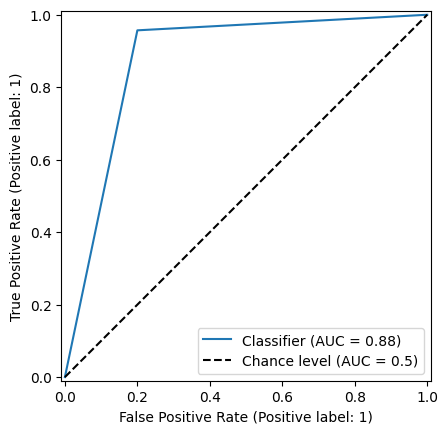

In [15]:
RocCurveDisplay.from_predictions(y_test, y_hat1, plot_chance_level=True)

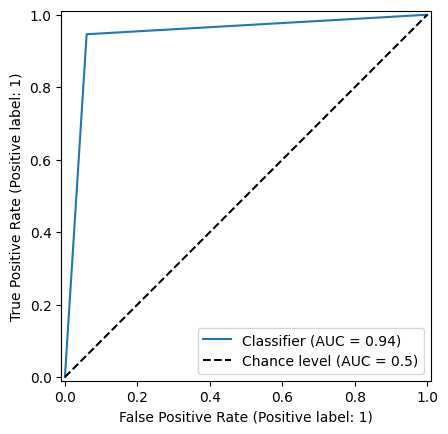

In [16]:
RocCurveDisplay.from_predictions(y_test, y_hat2, plot_chance_level=True)

You can also use the precision-recall curve:

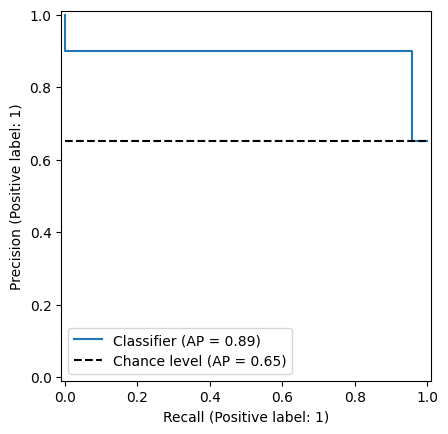

In [17]:
PrecisionRecallDisplay.from_predictions(y_test, y_hat1, plot_chance_level=True)

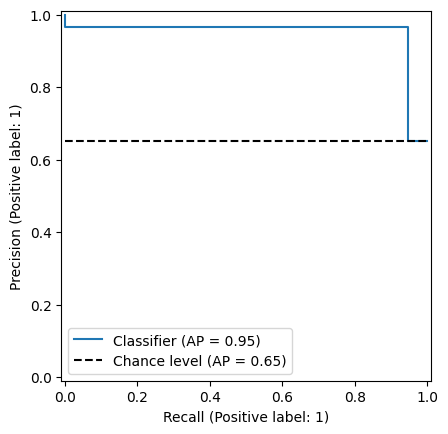

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, y_hat2, plot_chance_level=True)

## Multiclass classification
In multiclass classification, we can use the same idea as in binary classification. 
For accuracy, we can count the number of correct predictions and divide by the total number of predictions.
For AUC, we can use the one-vs-all approach.

In [19]:
from sklearn.datasets import load_iris

X_iris,y_iris = load_iris(as_frame=False, return_X_y=True)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris,y_iris)

In [20]:
mod_1_multiclass = DecisionTreeClassifier(max_depth=1).fit(X_train_iris,y_train_iris)
mod_2_multiclass = DecisionTreeClassifier(max_depth=5).fit(X_train_iris,y_train_iris)

In [21]:
y_hat1_iris = mod_1_multiclass.predict(X_test_iris)
y_hat2_iris = mod_2_multiclass.predict(X_test_iris)

print(y_hat1_iris)
print(y_hat2_iris)
acc_1 = accuracy_score(y_test_iris, y_hat1_iris)
acc_2 = accuracy_score(y_test_iris, y_hat2_iris)

print(f"Model 1 has acc {acc_1:.2f}, Model 2 has acc {acc_2:.2f}")

[0 0 0 2 0 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 0 0 2 2 2 2 2 0 0 2
 2]
[0 0 0 1 0 2 0 0 0 1 1 2 1 1 1 1 1 2 2 1 1 1 1 0 2 1 2 0 0 2 1 2 1 1 0 0 2
 1]
Model 1 has acc 0.55, Model 2 has acc 0.95


In [22]:
y_hat1_iris_proba = mod_1_multiclass.predict_proba(X_test_iris)
y_hat2_iris_proba = mod_2_multiclass.predict_proba(X_test_iris)


Note that we obtain a value for each class, which can be averaged.

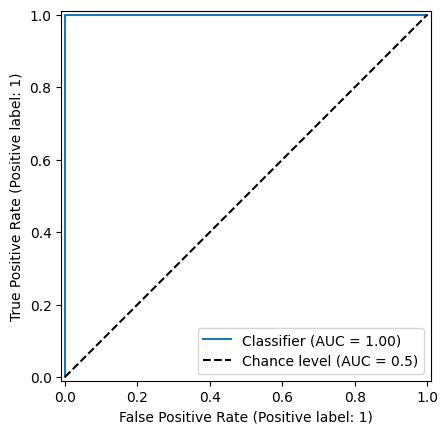

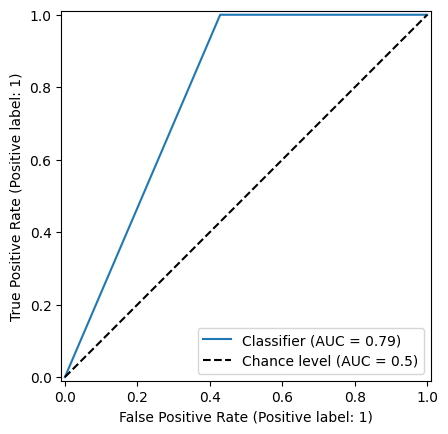

In [23]:
y_hat1_proba = mod_1_multiclass.predict_proba(X_test_iris)
y_hat2_proba = mod_2_multiclass.predict_proba(X_test_iris)

for idx in np.unique(y_test):
    display = RocCurveDisplay.from_predictions(
        y_test_iris==idx,
        y_hat1_iris_proba[:,idx],
        plot_chance_level=True,
    )

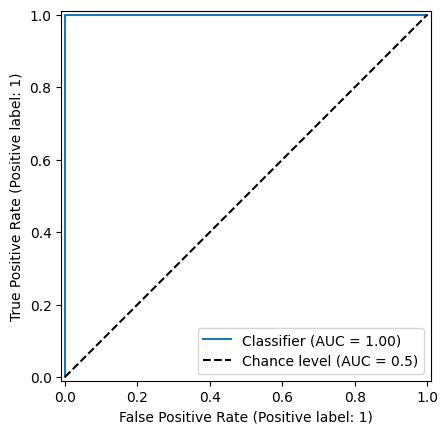

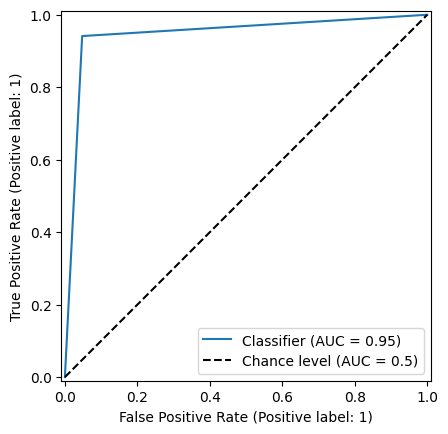

In [24]:
for idx in np.unique(y_test):
    display = RocCurveDisplay.from_predictions(
        y_test_iris==idx,
        y_hat2_iris_proba[:,idx],
        plot_chance_level=True,
    )

There are several ways to average the AUC values:
- micro: calculate the AUC for each class and average them
- macro: calculate the AUC for each class and average them
- weighted: calculate the AUC for each class and average them, weighting by the number of instances in each class

In [25]:
auc_multiclass_macro = roc_auc_score(y_test_iris, y_hat1_proba, multi_class="ovr", average="macro")
auc_multiclass_micro =roc_auc_score(y_test_iris, y_hat1_proba, multi_class="ovr", average="micro")
auc_multiclass_weigh =roc_auc_score(y_test_iris, y_hat1_proba, multi_class="ovr", average="weighted")

print(f"Model 1 has AUC(macro) : {auc_multiclass_macro:.2f}, AUC(micro) : {auc_multiclass_micro:.2f}, AUC(weighted): {auc_multiclass_weigh:.2f}")

auc_multiclass_macro = roc_auc_score(y_test_iris, y_hat2_proba, multi_class="ovr", average="macro")
auc_multiclass_micro =roc_auc_score(y_test_iris, y_hat2_proba, multi_class="ovr", average="micro")
auc_multiclass_weigh =roc_auc_score(y_test_iris, y_hat2_proba, multi_class="ovr", average="weighted")

print(f"Model 2 has AUC(macro) : {auc_multiclass_macro:.2f}, AUC(micro) : {auc_multiclass_micro:.2f}, AUC(weighted): {auc_multiclass_weigh:.2f}")


Model 1 has AUC(macro) : 0.83, AUC(micro) : 0.85, AUC(weighted): 0.83
Model 2 has AUC(macro) : 0.96, AUC(micro) : 0.96, AUC(weighted): 0.96


## Regression

In [26]:
from sklearn.datasets import load_diabetes
X_regr,y_regr = load_diabetes(return_X_y=True)
X_regr_train, X_regr_test, y_regr_train, y_regr_test = train_test_split(X_regr, y_regr)

In [27]:
from sklearn.tree import DecisionTreeRegressor
mod1_regr = DecisionTreeRegressor(max_depth=3).fit(X_regr_train,y_regr_train)
mod2_regr = DecisionTreeRegressor(max_depth=5).fit(X_regr_train,y_regr_train)

Text(0.5, 0, 'Truth')

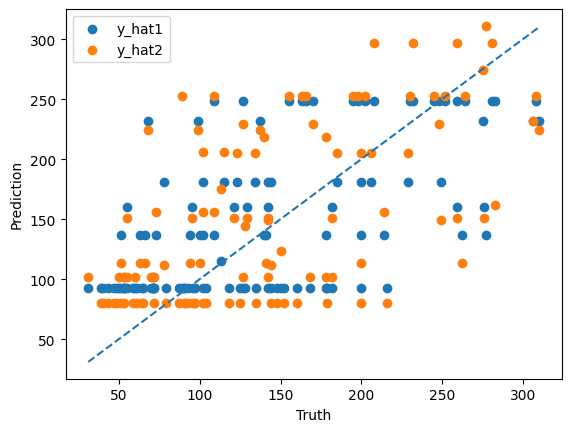

In [28]:
y_1_regr = mod1_regr.predict(X_regr_test)
y_2_regr = mod2_regr.predict(X_regr_test)

# plt.plot(y_regr_test, label="y")
plt.scatter(y_regr_test, y_1_regr, label="y_hat1")
plt.scatter(y_regr_test, y_2_regr, label="y_hat2")
plt.plot([y_regr_test.min(), y_regr_test.max()], [y_regr_test.min(), y_regr_test.max()], linestyle='dashed')
plt.legend()
plt.ylabel("Prediction")
plt.xlabel("Truth")

In [29]:
y_regr_test.min()

np.float64(31.0)

In [30]:
y_regr_test.max()

np.float64(310.0)

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

mse_1 = mean_squared_error(y_regr_test, y_1_regr)
mse_2 = mean_squared_error(y_regr_test, y_2_regr)

print(f"The MSEs are: Mod 1 {mse_1:.2f}, Mod 2 {mse_2:.2f}")

The MSEs are: Mod 1 3723.76, Mod 2 4175.81


In [32]:
mse_1 = mean_absolute_error(y_regr_test, y_1_regr)
mse_2 = mean_absolute_error(y_regr_test, y_2_regr)

print(f"The MAEs are: Mod 1 {mse_1:.2f}, Mod 2 {mse_2:.2f}")

The MAEs are: Mod 1 49.54, Mod 2 52.41


In [33]:

mse_1 = root_mean_squared_error(y_regr_test, y_1_regr)
mse_2 = root_mean_squared_error(y_regr_test, y_2_regr)

print(f"The RMSEs are: Mod 1 {mse_1:.2f}, Mod 2 {mse_2:.2f}")

The RMSEs are: Mod 1 61.02, Mod 2 64.62


In [34]:

mse_1 = r2_score(y_regr_test, y_1_regr)
mse_2 = r2_score(y_regr_test, y_2_regr)

print(f"The R2 are: Mod 1 {mse_1:.2f}, Mod 2 {mse_2:.2f}")

The R2 are: Mod 1 0.31, Mod 2 0.23


# Clustering

In [35]:
from sklearn.cluster import KMeans

mod1 = KMeans(n_clusters = 2).fit(X_iris)
mod2 = KMeans(n_clusters=2).fit(X_iris)

labels1 = mod1.predict(X_iris)
labels2 = mod1.predict(X_iris)

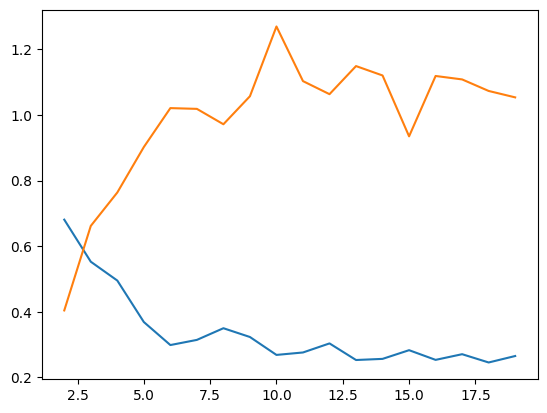

In [36]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

Ks = np.arange(2, 20)

sil_scores = []
db_idxs = []

for K in Ks:

    labels = KMeans(n_clusters=K).fit_predict(X_iris)

    sil_scores.append(silhouette_score(X_iris, labels))
    db_idxs.append(davies_bouldin_score(X_iris, labels))

plt.plot(Ks, sil_scores)
plt.plot(Ks, db_idxs)